Laboratory work 2.
PyTorch Workflow Exercise
Completed: Halka Artur

Variant: #3

<h1 style="color: red">Task 1. Create a straight line dataset.</h1>

Variant 3 - Noisy Linear Data With Range-Aware Sampling:

Goal: generate a noisy regression dataset in which both training and test data cover the full input range instead of being concentrated in one region.
Steps:
Create 300 points for x on [-15, 15] and compute y = -0.45x + 2.4 + epsilon, where epsilon follows a normal distribution with mean 0 and standard deviation 0.25.
Sort the dataset by x, then build the split by taking every fifth sample for the test set and the rest for training.
Confirm that both subsets contain negative, near-zero, and positive x values by printing summary statistics for each split.
Visualize the full dataset and emphasize the test samples with a larger marker size.
Add a short interpretation of how this splitting strategy supports a fairer evaluation of interpolation performance.
Hints: use torch.normal for noise, torch.argsort for sorting, and slice with a repeating pattern such as indices[::5].

Train X:
  min: -14.90
  max: 15.00
  mean: 0.05
  count: 240

Test X:
  min: -15.00
  max: 14.60
  mean: -0.20
  count: 60



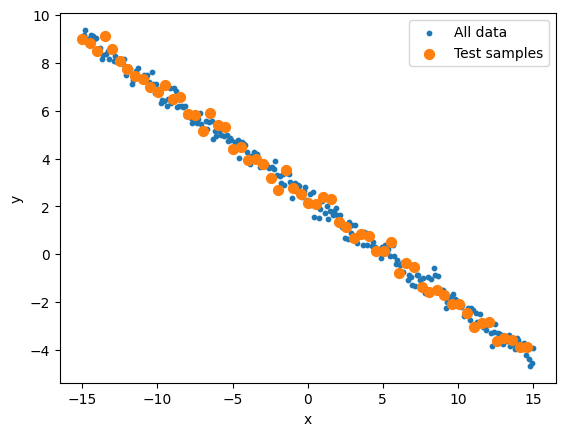

In [27]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(10563)

n = 300
x = torch.linspace(-15, 15, n)

epsilon = torch.normal(mean=0.0, std=0.25, size=(n,))
y = -0.45 * x + 2.4 + epsilon

# Sort by x
sorted_indices = torch.argsort(x)
x_sorted = x[sorted_indices]
y_sorted = y[sorted_indices]

# Every 5th point for test
test_idx = sorted_indices[::5]
train_mask = torch.ones(n, dtype=torch.bool)
train_mask[::5] = False

train_idx = sorted_indices[train_mask]
test_idx = sorted_indices[::5]

x_train, y_train = x[train_idx], y[train_idx]
x_test, y_test = x[test_idx], y[test_idx]

# 4. Summary statistics
def summarize(name, x_vals):
    print(f"{name}:")
    print(f"  min: {x_vals.min().item():.2f}")
    print(f"  max: {x_vals.max().item():.2f}")
    print(f"  mean: {x_vals.mean().item():.2f}")
    print(f"  count: {x_vals.numel()}")
    print()

summarize("Train X", x_train)
summarize("Test X", x_test)

plt.figure()

plt.scatter(x_sorted, y_sorted, s=10, label="All data")

plt.scatter(x_test, y_test, s=50, label="Test samples")

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

<h1 style="color: red">Task 2. Build a PyTorch model.</h1>

Variant 3 - Hidden Layer With Tanh and Output-Range Inspection:

Goal: construct a small regression model that uses nn.Tanh() and analyze how the activation changes the intermediate representation.
Steps:
Create a model with one input feature, one hidden layer of 6 units, a Tanh activation, and one output unit.
In the forward() method, save the hidden-layer activations in an intermediate variable before returning the final output.
Run a batch of inputs covering both negative and positive values and print the minimum and maximum hidden activation values.
Print the shapes of all trainable parameters and verify that they match the intended architecture.
Add a short note explaining why Tanh may behave differently from ReLU on centered data.
Hints: nn.Tanh() constrains hidden activations to [-1, 1], and using torch.min() and torch.max() on the hidden tensor makes the effect easy to inspect.

In [28]:
import torch.nn as nn

# Relu keeps only positive values, Tanh keeps values between -1 and 1
class TanhRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 6) # 1 in, 6 out
        self.act = nn.Tanh()
        self.fc2 = nn.Linear(6, 1) # 6 in, 1 out

    def forward(self, x):
        hidden = self.fc1(x)
        hidden_activated = self.act(hidden)
        out = self.fc2(hidden_activated)
        return out, hidden_activated


model = TanhRegressor()

x_batch = torch.linspace(-15, 15, n).unsqueeze(1)

y_pred, hidden_vals = model(x_batch)

print("Hidden activation min:", torch.min(hidden_vals).item())
print("Hidden activation max:", torch.max(hidden_vals).item())

for name, param in model.named_parameters():
    print(f"{name}: {tuple(param.shape)}")

Hidden activation min: -1.0
Hidden activation max: 1.0
fc1.weight: (6, 1)
fc1.bias: (6,)
fc2.weight: (1, 6)
fc2.bias: (1,)


<h1 style="color: red">Task 3. Create a loss function and an optimizer.</h1>

Variant 3 - Weighted Error Loss for Range-Sensitive Regression:

Goal: create and use a custom loss function that penalizes errors more heavily when they occur for larger-magnitude input values.
Steps:

Write a custom loss function that accepts y_pred, y_true, and the corresponding input tensor x.
Define the weight per sample as a function of input magnitude, for example 1 + |x|, and incorporate it into a weighted mean squared error.
Train a regression model with torch.optim.RMSprop(..., lr=0.001) for 250 epochs.
Log both the weighted loss and the unweighted MSE during training so you can compare optimization behavior under the custom objective.
Explain why weighting the loss by input magnitude may bias learning toward specific regions of the feature space.
Hints: a practical formula is ((weights * (y_pred - y_true) ** 2).mean()), and the custom loss remains fully differentiable, so a manual backward function is not required.

In [29]:
epsilon = torch.normal(mean=0.0, std=0.25, size=(n,1))
y_true = -0.45 * x_batch + 2.4 + epsilon

def weighted_mse(y_pred, y_true, x):
    weights = 1 + torch.abs(x)
    return (weights * (y_pred - y_true) ** 2).mean()

# Standard MSE
mse_loss = nn.MSELoss()

optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)

epochs = 250

for epoch in range(epochs):
    model.train()

    y_pred, _ = model(x_batch)

    loss_weighted = weighted_mse(y_pred, y_true, x_batch)
    loss_mse = mse_loss(y_pred, y_true)

    optimizer.zero_grad()
    loss_weighted.backward()
    optimizer.step()

    if epoch % 25 == 0:
        print(f"Epoch {epoch}: weighted_loss={loss_weighted.item():.4f}, mse={loss_mse.item():.4f}")

Epoch 0: weighted_loss=199.2659, mse=17.5067
Epoch 25: weighted_loss=162.0897, mse=14.0732
Epoch 50: weighted_loss=145.7006, mse=12.5720
Epoch 75: weighted_loss=133.3903, mse=11.4497
Epoch 100: weighted_loss=123.1504, mse=10.5199
Epoch 125: weighted_loss=114.2288, mse=9.7138
Epoch 150: weighted_loss=106.2670, mse=8.9945
Epoch 175: weighted_loss=99.0880, mse=8.3484
Epoch 200: weighted_loss=92.5431, mse=7.7584
Epoch 225: weighted_loss=86.3593, mse=7.2015


<h1 style="color: red">Task 4. Make predictions with the trained model on the test data.</h1>

Variant 3 - R-Squared and Predicted-vs-Actual Diagnostic Plot:

Goal: compute the coefficient of determination for regression predictions and visualize how closely predicted values align with actual targets.

Steps:
Generate predictions for the full test set in evaluation mode.
Implement an r_squared(y_true, y_pred) helper function from first principles rather than using a library shortcut.
Create a scatter plot with true values on one axis and predicted values on the other.
Draw the perfect-fit line y = x and annotate the plot with the computed R-squared value.
Explain briefly what it means if the points systematically fall above or below the perfect-fit line.
Hints: calculate ss_res and ss_tot with PyTorch or NumPy, and flatten tensors before plotting if they have shape (n, 1).


R^2: 0.5372


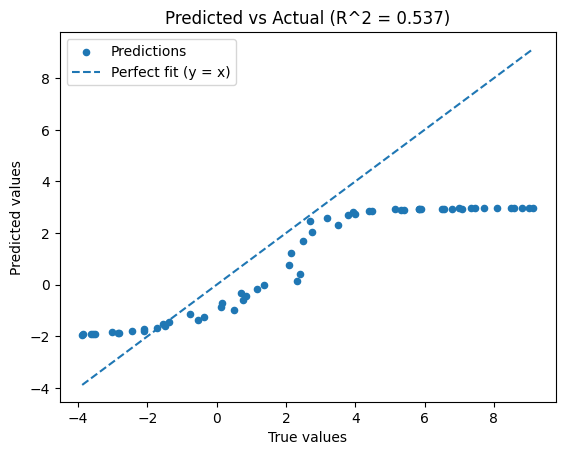

In [30]:
model.eval()

x_test = x_test.unsqueeze(1)
y_test = y_test.unsqueeze(1)

with torch.no_grad():
    y_pred_test, _ = model(x_test)

# R-squared
def r_squared(y_true, y_pred):
    y_true_mean = torch.mean(y_true)
    
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - y_true_mean) ** 2)
    
    return 1 - (ss_res / ss_tot)

r2 = r_squared(y_test, y_pred_test).item()
print(f"R^2: {r2:.4f}")


y_true_np = y_test.squeeze().numpy()
y_pred_np = y_pred_test.squeeze().numpy()


plt.figure()

plt.scatter(y_true_np, y_pred_np, s=20, label="Predictions")


min_val = min(y_true_np.min(), y_pred_np.min())
max_val = max(y_true_np.max(), y_pred_np.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", label="Perfect fit (y = x)")

plt.title(f"Predicted vs Actual (R^2 = {r2:.3f})")
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.legend()

plt.show()

<h1 style="color:red">Task 5. Save your trained model's state_dict() to file.</h1>

Variant 3 - Full Training-Resume Checkpoint With Optimizer State:

Goal: create a checkpoint that supports exact continuation of training, not only inference.

Steps:
Save a checkpoint containing the model state, optimizer state, current epoch number, and the latest training or validation loss.
Stop training deliberately after a chosen epoch and persist the checkpoint.
Reload the checkpoint into a new model and optimizer instance configured identically to the originals.
Continue training for additional epochs and compare the resumed run to a fresh run that starts from scratch.
Summarize what information is lost if you reload only the model weights but ignore the optimizer state.
Hints: use optimizer.load_state_dict(...) after constructing the optimizer, and store the epoch as an integer so resumption can continue from the correct point.

In [31]:
checkpoint_epoch = n // 2

model = TanhRegressor()
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)

for epoch in range(checkpoint_epoch + 1):
    model.train()
    y_pred, _ = model(x_batch)
    loss = weighted_mse(y_pred, y_true, x_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Save full training state
torch.save({
    'epoch': checkpoint_epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss.item()
}, "checkpoint.pth")

print(f"Checkpoint saved at epoch {checkpoint_epoch}")

# --- Resume from checkpoint ---
model_resume = TanhRegressor()
optimizer_resume = torch.optim.RMSprop(model_resume.parameters(), lr=0.001)

checkpoint = torch.load("checkpoint.pth")
model_resume.load_state_dict(checkpoint['model_state_dict'])
optimizer_resume.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch'] + 1

# Continue training
for epoch in range(start_epoch, 250):
    model_resume.train()
    y_pred, _ = model_resume(x_batch)
    loss = weighted_mse(y_pred, y_true, x_batch)

    optimizer_resume.zero_grad()
    loss.backward()
    optimizer_resume.step()

    if epoch % 25 == 0:
        print(f"[Resumed] Epoch {epoch}: loss={loss.item():.4f}")

Checkpoint saved at epoch 150
[Resumed] Epoch 175: loss=141.8173
[Resumed] Epoch 200: loss=132.4658
[Resumed] Epoch 225: loss=123.4363


<h1 style="color:Red"></h1>